In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

In [8]:
torch.set_default_device('mps')

In [3]:
alpha = 1.

In [33]:
def l2_norm(func):
    # func is a torch.tensor of size [N,1], of the function evaluated at N points on [-pi,pi]
    return torch.linalg.vector_norm(func)* np.sqrt(2*np.pi/func.shape[0])

In [39]:
class PINN(nn.Module):
    def __init__(self, width=4):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        
    def forward(self, theta):
        x1, x2 = torch.cos(theta), torch.sin(theta)
        x1x2 = torch.stack([x1, x2], axis=-1)
        outputs = self.l1(x1x2).squeeze() #* ((torch.sin(theta)-torch.sin(theta0))**2 + (torch.cos(theta)-torch.cos(theta0))**2) + y0

        return outputs / l2_norm(outputs)

In [5]:
def loss_fn(model, theta):
    g = model(theta)
    dg_dtheta = torch.autograd.grad(g, [theta], grad_outputs=torch.ones_like(g), create_graph=True)[0]
    d2g_dtheta2 = torch.autograd.grad(dg_dtheta, [theta], grad_outputs=torch.ones_like(dg_dtheta), create_graph=True)[0]
    r_t = (-alpha**2 * g)
    l_t = d2g_dtheta2
    return (r_t-l_t)**2

In [6]:
def display_solution(model):
    theta = torch.linspace(-np.pi, np.pi, 1000, requires_grad = True)
    g = model(theta).detach()
    max_g = 2*torch.max(torch.abs(g))
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot(torch.cos(theta).detach().cpu().numpy(), torch.sin(theta).detach().cpu().numpy(), label='ref')
    ax[0].plot((torch.cos(theta)*(1+g/max_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+g/max_g)).detach().cpu().numpy(), label='nn')
    ax[0].legend()
    ax[0].grid()
    ax[1].plot(theta.detach().cpu().numpy(), g.detach().cpu().numpy())
    ax[1].plot(theta.detach().cpu().numpy(), loss_fn(model, theta).detach().cpu().numpy())
    plt.show()

In [49]:
n_steps = 5000
model = PINN()

optimizer = optim.Adam(model.parameters(), lr=3e-4)

losses = []
for i in (pbar:=tqdm(range(n_steps))):
    optimizer.zero_grad()
    theta = (torch.rand(1000, requires_grad=True)-0.5)*2*torch.pi
    loss = loss_fn(model, theta)
    loss.mean().backward()
    losses.append(loss.mean().item())
    optimizer.step()
    pbar.set_description(f"Loss 1: {np.mean(losses[-20:]).item():.5e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

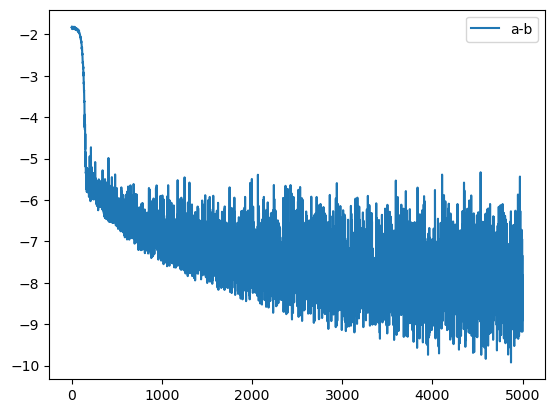

In [50]:
plt.plot(np.log(losses), label='a-b')
plt.legend()

$\displaystyle\operatorname{argmin}_{\theta_0} \sum_\theta \left[(y_{\theta_0}- \hat{y})^2\right]$

$y_{\theta_0} = \frac{1}{\sqrt{\pi}} \cos{\alpha (\theta+\theta_0)}$

In [11]:
def sol(theta):
    return (1/(torch.pi**0.5))*torch.cos(theta)

In [38]:
thetas = (torch.rand(1000)-0.5)*2*torch.pi
sols = sol(thetas)
print(l2_norm(sols))

tensor(0.9853)


In [51]:
class Theta0(nn.Module):
    def __init__(self, width=4):
        super().__init__()
        self.theta0 = nn.Parameter(torch.ones(1))
        
    def forward(self, theta):
        return self.theta0 + theta
        
def loss_theta(theta, theta0, y):
    return (((1/(torch.pi**0.5))*torch.cos(theta0(theta))-y)**2).sum()

n_steps = 10000
theta0_hat = Theta0()

optimizer = optim.Adam(theta0_hat.parameters(), lr=5e-4)

losses = []
for i in (pbar:=tqdm(range(n_steps))):
    optimizer.zero_grad()
    theta = (torch.rand(1000, requires_grad=True)-0.5)*2*torch.pi
    loss = loss_theta(theta, theta0_hat, model(theta))
    loss.backward()
    losses.append(loss.item())
    optimizer.step()
    pbar.set_description(f"Loss: {np.mean(losses[-20:]).item():.5e}, theta0: {theta0_hat.theta0.item():.5f}")

  0%|          | 0/10000 [00:00<?, ?it/s]

In [52]:
def sol_theta0(theta0, x):
    return (1/torch.pi**0.5)*torch.cos(alpha*(theta0_hat.theta0+x))

In [47]:
def display_solution(model, theta0):
    theta = torch.linspace(-np.pi, np.pi, 1000, requires_grad = True)
    g = model(theta).detach()
    max_g = 2*torch.max(torch.abs(g))
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot(torch.cos(theta).detach().cpu().numpy(), torch.sin(theta).detach().cpu().numpy(), label='circle')
    ax[0].plot((torch.cos(theta)*(1+g/max_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+g/max_g)).detach().cpu().numpy(), label='nn')
    ax[0].legend()
    ax[0].grid()
    ax[1].plot(theta.detach().cpu().numpy(), sol_theta0(theta0,theta).detach().cpu().numpy(), label='best_fit')
    ax[1].plot(theta.detach().cpu().numpy(), g.detach().cpu().numpy(), label='nn')
    ax[1].legend()
    plt.show()

In [44]:
theta = torch.linspace(-np.pi, np.pi, 1000, requires_grad = True)
g = model(theta).detach()
print(l2_norm(g))
    

tensor(1.0000)


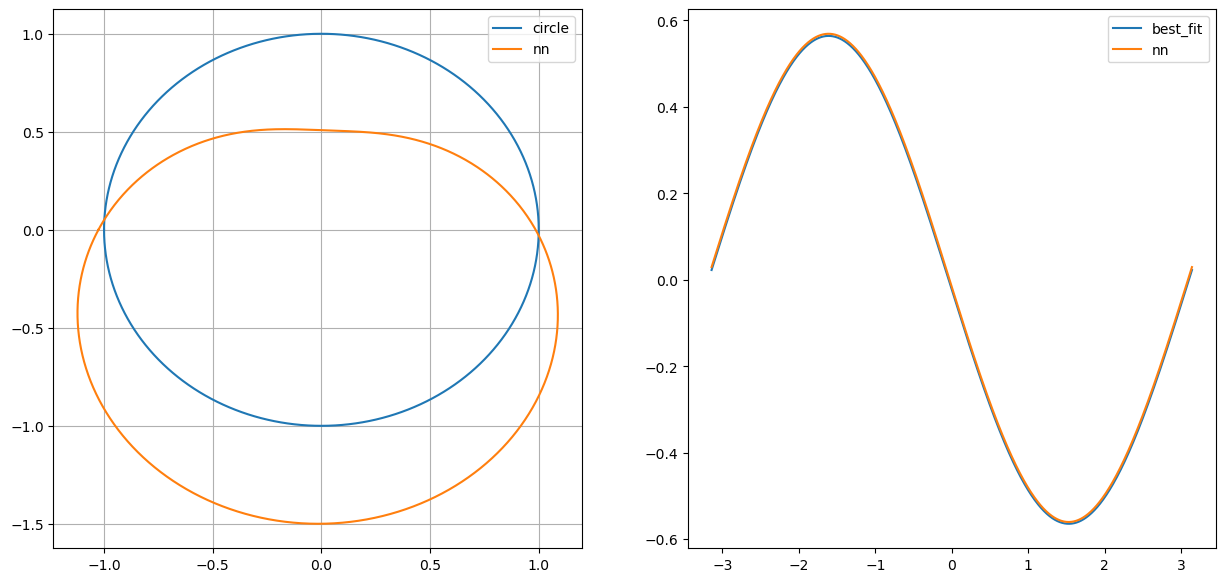

In [53]:
display_solution(model, theta0_hat)